In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import seaborn as sns
import scipy
from scipy import stats
import os
import pickle

In [31]:
data_labels = []
# path = '/mnt/d/Documents_D/Rojas_lab/data' # the base directory path
# path = '/Users/felixbarber/d/Documents_D/Barber_lab/data' # the base directory path

num_rep=4 # this is the number of repeats of each condition.
path='/Volumes/data_ssd2/Rojas_Lab/data' 
expt_id = '/250214_hydrolysis_tun_sensitivity' # the experiment title
# path='/Volumes/data_ssd1/Rojas_Lab/data' 
# expt_id = '/230324_hydrolase_Tun_growth_curves' # the experiment title


In [32]:
temp_path = './outputs'+expt_id+expt_id+'_growth_rate_df.pkl'
with open(temp_path, 'rb') as input:
    df_gr=pickle.load(input)
temp_path = './outputs'+expt_id+expt_id+'_sat_OD_df.pkl'
with open(temp_path, 'rb') as input:
    df_OD=pickle.load(input)
    
to_plot=[]
with open(path+expt_id+expt_id+'_curated.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for temp_row in csv_reader:
        to_plot.append(temp_row[0])
        line_count += 1
celltypes=[['Blank','bFB66','bFB7', 'bFB8'], ['', r'$WT$',r'$\Delta cwlO$', r'$\Delta lytE$']]

In [33]:
df=df_gr.copy()
df['Maximum OD'] = df_OD['Max. density']
temp=[]
for i0 in range(len(df)):
    if df['Condition'].iloc[i0]=='Blank':
        temp.append(i0)
df=df.reset_index(drop=True)
df=df.drop(temp)
df.head(10)
df=df.reset_index(drop=True)
temp1, temp2 = [], []        
for i0 in range(len(df)):    
    ind=np.nonzero([it in df['Condition'].iloc[i0] for it in celltypes[0]])[0][0]
    temp1.append(celltypes[1][ind])
    temp2.append(df['Condition'].iloc[i0][len(celltypes[0][ind])+1:])
df['Celltype'] = temp1
df['Growth condition'] = temp2

Changing the order of things

In [34]:
temp=df['Growth condition'].unique()
sel_conds=[3,0,1,2]
temp_ord=[temp[ind] for ind in sel_conds]

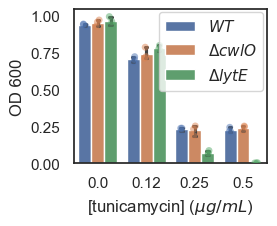

In [35]:
fig=plt.figure(figsize=[2.5,2.0])
sns.set(font_scale=1.0)
sns.set_style('white')
colors=sns.color_palette()
temp_hue=[r'$WT$', r'$\Delta cwlO$',r'$\Delta lytE$']
sns.barplot(data=df,x='Growth condition',y='Maximum OD',hue='Celltype', order=temp_ord, hue_order=temp_hue,capsize=0.15)
sns.stripplot(data=df,x='Growth condition',y='Maximum OD',hue='Celltype', order=temp_ord, hue_order=temp_hue,dodge=True,alpha=0.5,edgecolor='black',legend=None)
plt.ylabel('OD 600')
plt.xlabel(r'[tunicamycin] ($\mu g/mL$)')
xtick_locs,vals=plt.xticks()
# plt.xticks(rotation = 90)
plt.xticks(ticks=xtick_locs,labels=[0.0,0.12,0.25,0.5])
plt.legend(loc=[0.44,0.47])
# plt.legend(loc=[1.1,0.1])
fig.savefig('./outputs'+expt_id+expt_id+'_OD_plot_paper.pdf',bbox_inches='tight')

In [28]:
outs_anova=[]
temp_hue = [r'$WT$',r'$\Delta cwlO$', r'$\Delta lytE$']
print(temp_hue)
for conc in df['Growth condition'].unique():
    samples=[np.asarray(df[(df['Growth condition']==conc)*df.Celltype==temp_hue[i0]]['Maximum OD']) for i0 in range(len(temp_hue))]
    # print(samples)
    outs_anova.append(scipy.stats.f_oneway(*samples, axis=0))
    print(conc,outs_anova[-1])
    if outs_anova[-1][1]<0.01:
        print(scipy.stats.tukey_hsd(*samples))
        print(scipy.stats.tukey_hsd(*samples).pvalue)
    else:
        print('not significant')

['$WT$', '$\\Delta cwlO$', '$\\Delta lytE$']
0.125ug/mL Tunicamycin F_onewayResult(statistic=52.432181403623495, pvalue=1.0973523595658336e-05)
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.009     0.959    -0.079     0.096
 (0 - 2)      0.282     0.000     0.195     0.370
 (1 - 0)     -0.009     0.959    -0.096     0.079
 (1 - 2)      0.274     0.000     0.186     0.361
 (2 - 0)     -0.282     0.000    -0.370    -0.195
 (2 - 1)     -0.274     0.000    -0.361    -0.186

[[1.00000000e+00 9.58638103e-01 2.26955282e-05]
 [9.58638103e-01 1.00000000e+00 2.92712158e-05]
 [2.26955282e-05 2.92712158e-05 1.00000000e+00]]
0.25ug/mL Tunicamycin F_onewayResult(statistic=203.7087261174388, pvalue=3.207828491225779e-08)
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.092     0.008    -0.156    -0.028
 (0 - 2)      0.345     0.00